In [ ]:
!pip install torch transformers scikit-learn matplotlib

In [ ]:
# Load datasets
n = 1
while n < 2:
  from google.colab import files
  uploaded = files.upload()  # Opens a file upload prompt
  n += 1

Saving METLIN_RT_lipid_test_with_rdkit.csv to METLIN_RT_lipid_test_with_rdkit.csv
Saving METLIN_RT_lipid_train_with_rdkit.csv to METLIN_RT_lipid_train_with_rdkit.csv


In [ ]:
import pandas as pd

# Load full datasets
train_df = pd.read_csv('/content/METLIN_RT_lipid_train_with_rdkit.csv')#.sample(n=1_000)
test_df  = pd.read_csv('/content/METLIN_RT_lipid_test_with_rdkit.csv')#.sample(n=1_000)

In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from sklearn.preprocessing import MinMaxScaler

# Inputs
train_smiles = train_df['smile'].tolist()
test_smiles  = test_df['smile'].tolist()

# Targets (replace 'ccs' with 'rt')
target_cols = ['rt', 'mol_weight', 'polar_surface_area', 'h_bond_donors',
               'h_bond_acceptors', 'rotatable_bonds', 'aromatic_rings', 'heavy_atoms']
y_train_orig = train_df[target_cols].values.astype(float)
y_test_orig  = test_df[target_cols].values.astype(float)

# Min-max scaling
scaler = MinMaxScaler()
y_train = scaler.fit_transform(y_train_orig).astype(np.float32)
y_test  = scaler.transform(y_test_orig).astype(np.float32)

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')

# Dataset
class PeptideDataset(Dataset):
    def __init__(self, smiles, targets, tokenizer, max_len=128):
        self.smiles = smiles
        self.targets = targets
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self): return len(self.smiles)
    def __getitem__(self, idx):
        enc = self.tokenizer(self.smiles[idx],
                             padding='max_length',
                             truncation=True,
                             max_length=self.max_len,
                             return_tensors='pt')
        return {
            'input_ids':     enc['input_ids'].squeeze(0),
            'attention_mask':enc['attention_mask'].squeeze(0),
            'labels':        torch.tensor(self.targets[idx], dtype=torch.float32)
        }

# Datasets and loaders
train_ds = PeptideDataset(train_smiles, y_train, tokenizer)
test_ds  = PeptideDataset(test_smiles,  y_test,  tokenizer)

batch_size = 16
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/166 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/501 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel

class ChemBERTaRTRegressor(nn.Module):
    def __init__(self, n_outputs=8):
        super(ChemBERTaRTRegressor, self).__init__()
        # Load pre-trained ChemBERTa model
        self.bert = AutoModel.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')
        hidden_size = self.bert.config.hidden_size  # Typically 768

        # Linear regressor head for N targets (default: 8)
        self.regressor = nn.Linear(hidden_size, n_outputs)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb = outputs.last_hidden_state[:, 0, :]  # Use [CLS] token
        out = self.regressor(cls_emb)  # (batch_size, n_outputs)
        return out

# Instantiate model
model = ChemBERTaRTRegressor(n_outputs=8)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Optimizer and loss
optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-5)
criterion = nn.MSELoss()

pytorch_model.bin:   0%|          | 0.00/179M [00:00<?, ?B/s]

In [ ]:
import torch.nn as nn
import torch
from sklearn.metrics import r2_score, mean_absolute_error
from transformers import AutoModel
import pandas as pd
import numpy as np  # ← needed for vstack

# Model definition
class ChemBERTaRTRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')
        hs = self.bert.config.hidden_size
        self.regressor = nn.Linear(hs, 8)  # 8 targets

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:,0,:]
        return self.regressor(cls)

# Setup
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = ChemBERTaRTRegressor().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-5)
criterion = nn.MSELoss()

# Updated label names (ccs → rt)
label_names = ['rt','mol_weight','polar_surface_area','h_bond_donors',
               'h_bond_acceptors','rotatable_bonds','aromatic_rings','heavy_atoms']

def get_preds_and_truth(loader):
    model.eval()
    ys, yps = [], []
    with torch.no_grad():
        for b in loader:
            inp = b['input_ids'].to(device)
            msk = b['attention_mask'].to(device)
            out = model(inp, msk).cpu().numpy()
            ys.append(b['labels'].cpu().numpy())
            yps.append(out)
    return np.vstack(ys), np.vstack(yps)

In [ ]:
import torch
import torch.nn as nn
from sklearn.metrics import r2_score, mean_absolute_error
from transformers import AutoModel
import pandas as pd
import numpy as np

# Model
class ChemBERTaRTRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')
        hs = self.bert.config.hidden_size
        self.regressor  = nn.Linear(hs, 8)  # 8 targets

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        return self.regressor(cls)

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ChemBERTaRTRegressor().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-5)
criterion = nn.MSELoss()

# Replace with correct label names used in training
label_names = ['rt', 'mol_weight', 'polar_surface_area', 'h_bond_donors',
               'h_bond_acceptors', 'rotatable_bonds', 'aromatic_rings', 'heavy_atoms']

# Helper function for prediction
def get_preds_and_truth(loader):
    model.eval()
    ys, yps = [], []
    with torch.no_grad():
        for b in loader:
            inp = b['input_ids'].to(device)
            msk = b['attention_mask'].to(device)
            out = model(inp, msk).cpu().numpy()
            ys.append(b['labels'].cpu().numpy())
            yps.append(out)
    return np.vstack(ys), np.vstack(yps)

# DataFrames to store metrics
r2_train_df = pd.DataFrame(columns=['epoch', 'loss'] + label_names)
r2_test_df  = pd.DataFrame(columns=['epoch', 'loss'] + label_names)
mae_train_df = pd.DataFrame(columns=['epoch', 'loss'] + label_names)
mae_test_df  = pd.DataFrame(columns=['epoch', 'loss'] + label_names)

# Training loop
num_epochs = 15
for epoch in range(1, num_epochs + 1):
    model.train()
    total_loss = 0.0
    for b in train_loader:
        optimizer.zero_grad()
        out = model(b['input_ids'].to(device), b['attention_mask'].to(device))
        loss = criterion(out, b['labels'].to(device))
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * b['input_ids'].size(0)
    avg_loss = total_loss / len(train_ds)

    # Predictions
    y_tr, yh_tr = get_preds_and_truth(train_loader)
    y_te, yh_te = get_preds_and_truth(test_loader)

    # Inverse transform
    y_tr_inv  = scaler.inverse_transform(y_tr)
    yh_tr_inv = scaler.inverse_transform(yh_tr)
    y_te_inv  = scaler.inverse_transform(y_te)
    yh_te_inv = scaler.inverse_transform(yh_te)

    # Store R² and MAE for each target
    r2_train_row  = {'epoch': epoch, 'loss': avg_loss}
    r2_test_row   = {'epoch': epoch, 'loss': avg_loss}
    mae_train_row = {'epoch': epoch, 'loss': avg_loss}
    mae_test_row  = {'epoch': epoch, 'loss': avg_loss}

    for i, name in enumerate(label_names):
        r2_train_row[name]  = r2_score(y_tr_inv[:, i], yh_tr_inv[:, i])
        r2_test_row[name]   = r2_score(y_te_inv[:, i], yh_te_inv[:, i])
        mae_train_row[name] = mean_absolute_error(y_tr_inv[:, i], yh_tr_inv[:, i])
        mae_test_row[name]  = mean_absolute_error(y_te_inv[:, i], yh_te_inv[:, i])

    r2_train_df.loc[len(r2_train_df)]   = r2_train_row
    r2_test_df.loc[len(r2_test_df)]     = r2_test_row
    mae_train_df.loc[len(mae_train_df)] = mae_train_row
    mae_test_df.loc[len(mae_test_df)]   = mae_test_row

    # Print RT metrics for quick monitoring
    print(f"\n=== Epoch {epoch}/{num_epochs} (Loss {avg_loss:.4f}) ===")
    print(f"RT R² Train: {r2_train_row['rt']:.4f} | Test: {r2_test_row['rt']:.4f}")
    print(f"RT MAE Train: {mae_train_row['rt']:.4f} | Test: {mae_test_row['rt']:.4f}")

# Save all results
r2_train_df.to_csv('chemberta_rt_rdkit_rsquare_train.csv', index=False)
r2_test_df.to_csv('chemberta_rt_rdkit_rsquare_test.csv', index=False)
mae_train_df.to_csv('chemberta_rt_rdkit_mae_train.csv', index=False)
mae_test_df.to_csv('chemberta_rt_rdkit_mae_test.csv', index=False)

print("\n✅ Saved all R² and MAE CSV files.")


=== Epoch 1/15 (Loss 0.0105) ===
RT R² Train: 0.3134 | Test: 0.3214
RT MAE Train: 114.5673 | Test: 114.9211

=== Epoch 2/15 (Loss 0.0026) ===
RT R² Train: 0.7011 | Test: 0.6956
RT MAE Train: 69.8448 | Test: 71.5863

=== Epoch 3/15 (Loss 0.0016) ===
RT R² Train: 0.7705 | Test: 0.7574
RT MAE Train: 59.8188 | Test: 62.0591

=== Epoch 4/15 (Loss 0.0013) ===
RT R² Train: 0.8307 | Test: 0.8071
RT MAE Train: 49.5270 | Test: 53.6200

=== Epoch 5/15 (Loss 0.0011) ===
RT R² Train: 0.8569 | Test: 0.8244
RT MAE Train: 45.0750 | Test: 50.2769

=== Epoch 6/15 (Loss 0.0009) ===
RT R² Train: 0.8599 | Test: 0.8181
RT MAE Train: 45.7959 | Test: 51.4371

=== Epoch 7/15 (Loss 0.0008) ===
RT R² Train: 0.8805 | Test: 0.8308
RT MAE Train: 41.6176 | Test: 48.7038

=== Epoch 8/15 (Loss 0.0007) ===
RT R² Train: 0.8621 | Test: 0.8126
RT MAE Train: 47.3430 | Test: 54.5320

=== Epoch 9/15 (Loss 0.0007) ===
RT R² Train: 0.8760 | Test: 0.8173
RT MAE Train: 44.8273 | Test: 53.1446

=== Epoch 10/15 (Loss 0.0006) ===


CHemberta without RDKit >>>>>

In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from sklearn.preprocessing import MinMaxScaler

# Inputs
train_smiles = train_df['smile'].tolist()
test_smiles  = test_df['smile'].tolist()

# Target: Only RT
target_cols = ['rt']
y_train_orig = train_df[target_cols].values.astype(float)
y_test_orig  = test_df[target_cols].values.astype(float)

# Min-max scaling
scaler = MinMaxScaler()
y_train = scaler.fit_transform(y_train_orig).astype(np.float32)
y_test  = scaler.transform(y_test_orig).astype(np.float32)

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')

# Dataset
class PeptideDataset(Dataset):
    def __init__(self, smiles, targets, tokenizer, max_len=128):
        self.smiles = smiles
        self.targets = targets
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        enc = self.tokenizer(self.smiles[idx],
                             padding='max_length',
                             truncation=True,
                             max_length=self.max_len,
                             return_tensors='pt')
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.targets[idx], dtype=torch.float32)
        }

# Datasets and loaders
train_ds = PeptideDataset(train_smiles, y_train, tokenizer)
test_ds  = PeptideDataset(test_smiles,  y_test,  tokenizer)

batch_size = 16
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel

class ChemBERTaRTRegressor(nn.Module):
    def __init__(self, n_outputs=1):  # RT is a single target
        super(ChemBERTaRTRegressor, self).__init__()
        # Load pre-trained ChemBERTa model
        self.bert = AutoModel.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')
        hidden_size = self.bert.config.hidden_size  # Typically 768

        # Linear regressor head for RT
        self.regressor = nn.Linear(hidden_size, n_outputs)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb = outputs.last_hidden_state[:, 0, :]  # Use [CLS] token
        out = self.regressor(cls_emb)  # (batch_size, 1)
        return out

# Instantiate model for RT prediction
model = ChemBERTaRTRegressor(n_outputs=1)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Optimizer and loss
optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-5)
criterion = nn.MSELoss()

In [ ]:
import torch.nn as nn
import torch
from sklearn.metrics import r2_score, mean_absolute_error
from transformers import AutoModel
import numpy as np  # Needed for vstack

# Model definition for RT-only prediction
class ChemBERTaRTRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')
        hs = self.bert.config.hidden_size
        self.regressor  = nn.Linear(hs, 1)  # Output size is 1 for RT

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]  # CLS token
        return self.regressor(cls)

# Setup
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = ChemBERTaRTRegressor().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-5)
criterion = nn.MSELoss()

# Evaluation function
def get_preds_and_truth(loader):
    model.eval()
    ys, yps = [], []
    with torch.no_grad():
        for b in loader:
            inp = b['input_ids'].to(device)
            msk = b['attention_mask'].to(device)
            out = model(inp, msk).cpu().numpy()
            ys.append(b['labels'].cpu().numpy())
            yps.append(out)
    return np.vstack(ys), np.vstack(yps)

In [ ]:
import torch
import torch.nn as nn
from sklearn.metrics import r2_score, mean_absolute_error
from transformers import AutoModel
import pandas as pd
import numpy as np

# Model for RT-only prediction
class ChemBERTaRTRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')
        hs = self.bert.config.hidden_size
        self.regressor  = nn.Linear(hs, 1)  # Single RT output

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        return self.regressor(cls)

# Setup
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = ChemBERTaRTRegressor().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2.5e-5)
criterion = nn.MSELoss()

# Evaluation function
def get_preds_and_truth(loader):
    model.eval()
    ys, yps = [], []
    with torch.no_grad():
        for b in loader:
            inp = b['input_ids'].to(device)
            msk = b['attention_mask'].to(device)
            out = model(inp, msk).cpu().numpy()
            ys.append(b['labels'].cpu().numpy())
            yps.append(out)
    return np.vstack(ys), np.vstack(yps)

# DataFrames to track per-epoch R² and MAE for RT
rsq_train_df = pd.DataFrame(columns=['epoch', 'loss', 'rt'])
rsq_test_df  = pd.DataFrame(columns=['epoch', 'loss', 'rt'])
mae_train_df = pd.DataFrame(columns=['epoch', 'loss', 'rt'])
mae_test_df  = pd.DataFrame(columns=['epoch', 'loss', 'rt'])

# Training loop
num_epochs = 15
for epoch in range(1, num_epochs + 1):
    model.train()
    total_loss = 0.0
    for b in train_loader:
        optimizer.zero_grad()
        out = model(
            b['input_ids'].to(device),
            b['attention_mask'].to(device)
        )
        loss = criterion(out, b['labels'].to(device))
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * b['input_ids'].size(0)
    avg_loss = total_loss / len(train_ds)

    # Predictions
    y_tr, yh_tr = get_preds_and_truth(train_loader)
    y_te, yh_te = get_preds_and_truth(test_loader)

    # Inverse scale
    y_tr_inv  = scaler.inverse_transform(y_tr)
    yh_tr_inv = scaler.inverse_transform(yh_tr)
    y_te_inv  = scaler.inverse_transform(y_te)
    yh_te_inv = scaler.inverse_transform(yh_te)

    # Metrics for RT only
    r2_train = r2_score(y_tr_inv, yh_tr_inv)
    mae_train = mean_absolute_error(y_tr_inv, yh_tr_inv)
    r2_test = r2_score(y_te_inv, yh_te_inv)
    mae_test = mean_absolute_error(y_te_inv, yh_te_inv)

    # Save per-epoch to CSV-compatible format
    rsq_train_df.loc[len(rsq_train_df)] = {'epoch': epoch, 'loss': avg_loss, 'rt': r2_train}
    rsq_test_df.loc[len(rsq_test_df)]   = {'epoch': epoch, 'loss': avg_loss, 'rt': r2_test}
    mae_train_df.loc[len(mae_train_df)] = {'epoch': epoch, 'loss': avg_loss, 'rt': mae_train}
    mae_test_df.loc[len(mae_test_df)]   = {'epoch': epoch, 'loss': avg_loss, 'rt': mae_test}

    # Print summary
    print(f"\n=== Epoch {epoch}/{num_epochs} (Loss {avg_loss:.4f}) ===")
    print(f"Train: R²={r2_train:.4f} | MAE={mae_train:.4f}")
    print(f"Test : R²={r2_test:.4f}  | MAE={mae_test:.4f}")

# Save all 4 metric files
rsq_train_df.to_csv('chemberta_rt_rsquare_train.csv', index=False)
rsq_test_df.to_csv('chemberta_rt_rsquare_test.csv', index=False)
mae_train_df.to_csv('chemberta_rt_mae_train.csv', index=False)
mae_test_df.to_csv('chemberta_rt_mae_test.csv', index=False)

print("\n✅ Saved RT-only R² and MAE metrics for train and test.")


=== Epoch 1/15 (Loss 0.0230) ===
Train: R²=0.5497 | MAE=91.1158
Test : R²=0.5499  | MAE=92.6049

=== Epoch 2/15 (Loss 0.0085) ===
Train: R²=0.7408 | MAE=64.2555
Test : R²=0.7258  | MAE=66.6550

=== Epoch 3/15 (Loss 0.0062) ===
Train: R²=0.8092 | MAE=55.8669
Test : R²=0.7812  | MAE=60.3645

=== Epoch 4/15 (Loss 0.0050) ===
Train: R²=0.7905 | MAE=60.9461
Test : R²=0.7576  | MAE=65.5119

=== Epoch 5/15 (Loss 0.0043) ===
Train: R²=0.8467 | MAE=50.7233
Test : R²=0.7974  | MAE=57.7482

=== Epoch 6/15 (Loss 0.0038) ===
Train: R²=0.8758 | MAE=42.2784
Test : R²=0.8153  | MAE=51.2067

=== Epoch 7/15 (Loss 0.0034) ===
Train: R²=0.8955 | MAE=39.6641
Test : R²=0.8278  | MAE=49.8351

=== Epoch 8/15 (Loss 0.0031) ===
Train: R²=0.8987 | MAE=37.7353
Test : R²=0.8276  | MAE=48.0993

=== Epoch 9/15 (Loss 0.0029) ===
Train: R²=0.8595 | MAE=48.0955
Test : R²=0.7861  | MAE=57.3068

=== Epoch 10/15 (Loss 0.0027) ===
Train: R²=0.8859 | MAE=41.1767
Test : R²=0.8034  | MAE=52.0215

=== Epoch 11/15 (Loss 0.0025

In [ ]:
# Load datasets
n = 1
while n < 9:
  from google.colab import files
  uploaded = files.upload()  # Opens a file upload prompt
  n += 1

KeyboardInterrupt: 

✅ Saved boxplot data → chemberta_rdkit_boxplot_data_long.csv


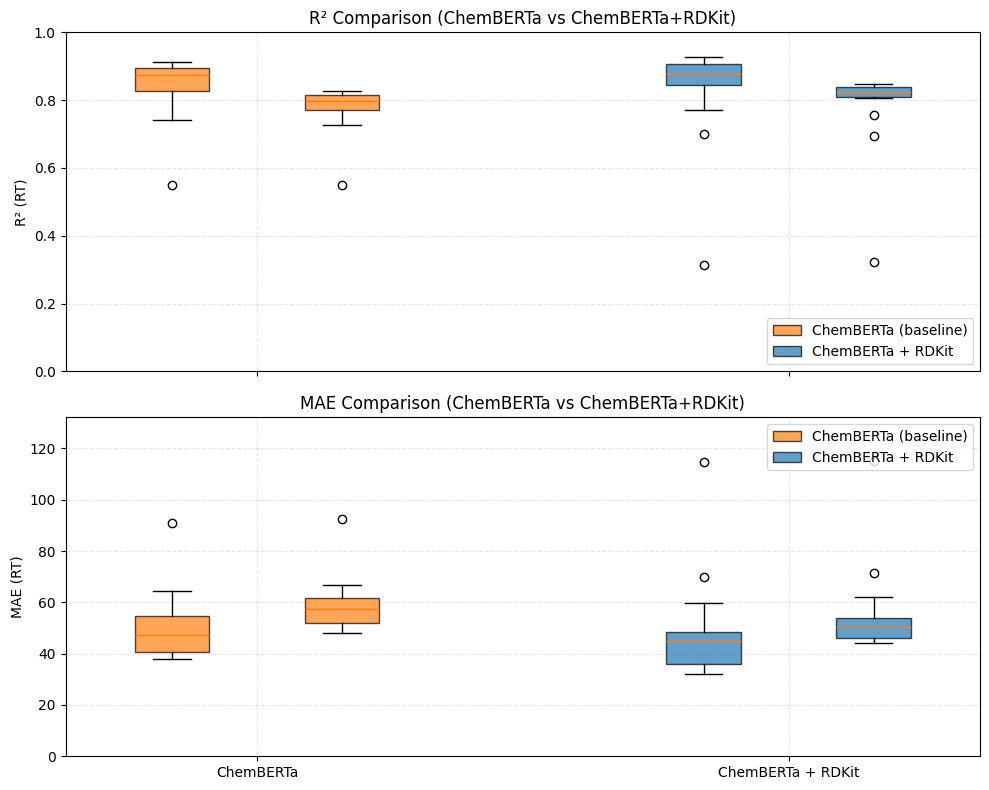

✅ Saved R² scatter CSV → chemberta_rdkit_scatter_r2.csv
✅ Saved MAE scatter CSV → chemberta_rdkit_scatter_mae.csv


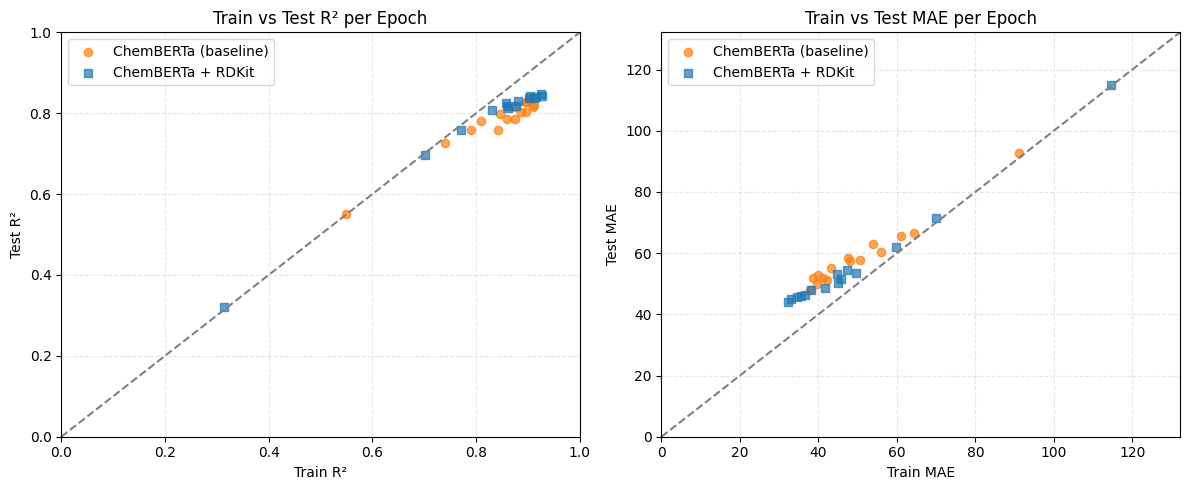

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load CSV files
rsq_train = pd.read_csv('/content/chemberta_rt_rsquare_train.csv')
rsq_test = pd.read_csv('/content/chemberta_rt_rsquare_test.csv')
rsq_train_rdkit = pd.read_csv('/content/chemberta_rt_rdkit_rsquare_train.csv')
rsq_test_rdkit = pd.read_csv('/content/chemberta_rt_rdkit_rsquare_test.csv')

mae_train = pd.read_csv('/content/chemberta_rt_mae_train.csv')
mae_test = pd.read_csv('/content/chemberta_rt_mae_test.csv')
mae_train_rdkit = pd.read_csv('/content/chemberta_rt_rdkit_mae_train.csv')
mae_test_rdkit = pd.read_csv('/content/chemberta_rt_rdkit_mae_test.csv')

# Extract arrays
chem_r2_train = rsq_train['rt'].values
chem_r2_test = rsq_test['rt'].values
chem_rdkit_r2_train = rsq_train_rdkit['rt'].values
chem_rdkit_r2_test = rsq_test_rdkit['rt'].values

chem_mae_train = mae_train['rt'].values
chem_mae_test = mae_test['rt'].values
chem_rdkit_mae_train = mae_train_rdkit['rt'].values
chem_rdkit_mae_test = mae_test_rdkit['rt'].values

epochs = np.arange(1, len(chem_r2_train) + 1)

# ============================================================
# 1) SAVE BOXPLOT LONG-FORMAT CSV
# ============================================================

rows = []

for model_name, r2_tr, r2_te, mae_tr, mae_te in [
    ("ChemBERTa", chem_r2_train, chem_r2_test, chem_mae_train, chem_mae_test),
    ("ChemBERTa+RDKit", chem_rdkit_r2_train, chem_rdkit_r2_test, chem_rdkit_mae_train, chem_rdkit_mae_test)
]:
    for split_name, r2vals, maevals in [
        ("Train", r2_tr, mae_tr),
        ("Test",  r2_te, mae_te)
    ]:
        for epoch_idx, (r2_val, mae_val) in enumerate(zip(r2vals, maevals), start=1):
            rows.append({
                "model": model_name,
                "split": split_name,
                "epoch": epoch_idx,
                "metric": "R2",
                "value": r2_val
            })
            rows.append({
                "model": model_name,
                "split": split_name,
                "epoch": epoch_idx,
                "metric": "MAE",
                "value": mae_val
            })

boxplot_df = pd.DataFrame(rows)
boxplot_df.to_csv("chemberta_rdkit_boxplot_data_long.csv", index=False)
print("✅ Saved boxplot data → chemberta_rdkit_boxplot_data_long.csv")

# ============================================================
# 2) COMPACT GROUPED BOXPLOTS
# ============================================================

fig, (ax_r2, ax_mae) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

categories = ['ChemBERTa', 'ChemBERTa + RDKit']
n_cat = len(categories)

chunk_width = 2.5
centers = np.arange(n_cat) * chunk_width
offsets = np.array([-0.4, 0.4])  # Train, Test

pos_chem_train = centers[0] + offsets[0]
pos_chem_test  = centers[0] + offsets[1]
pos_rdkit_train = centers[1] + offsets[0]
pos_rdkit_test  = centers[1] + offsets[1]

# ---------------- R² boxplots ----------------
r2_data = [
    chem_r2_train, chem_r2_test,
    chem_rdkit_r2_train, chem_rdkit_r2_test
]

# UPDATED COLOURS: baseline=orange, RDKit=blue
r2_colors = ['#ff7f0e', '#ff7f0e', '#1f77b4', '#1f77b4']

r2_positions = [pos_chem_train, pos_chem_test, pos_rdkit_train, pos_rdkit_test]

bp_r2 = ax_r2.boxplot(r2_data, positions=r2_positions, widths=0.35, patch_artist=True)
for box, col in zip(bp_r2['boxes'], r2_colors):
    box.set_facecolor(col)
    box.set_alpha(0.7)

ax_r2.set_title("R² Comparison (ChemBERTa vs ChemBERTa+RDKit)")
ax_r2.set_ylabel("R² (RT)")
ax_r2.set_ylim(0.0, 1.0)
ax_r2.set_xticks(centers)
ax_r2.set_xticklabels(categories)
ax_r2.grid(True, linestyle='--', alpha=0.3)
ax_r2.legend(
    [bp_r2['boxes'][0], bp_r2['boxes'][2]],
    ["ChemBERTa (baseline)", "ChemBERTa + RDKit"],
    loc="lower right"
)

# ---------------- MAE boxplots ----------------
mae_data = [
    chem_mae_train, chem_mae_test,
    chem_rdkit_mae_train, chem_rdkit_mae_test
]

bp_mae = ax_mae.boxplot(mae_data, positions=r2_positions, widths=0.35, patch_artist=True)
for box, col in zip(bp_mae['boxes'], r2_colors):
    box.set_facecolor(col)
    box.set_alpha(0.7)

max_mae = np.max([chem_mae_train.max(), chem_mae_test.max(),
                  chem_rdkit_mae_train.max(), chem_rdkit_mae_test.max()])

ax_mae.set_title("MAE Comparison (ChemBERTa vs ChemBERTa+RDKit)")
ax_mae.set_ylabel("MAE (RT)")
ax_mae.set_ylim(0, max_mae * 1.15)
ax_mae.set_xticks(centers)
ax_mae.set_xticklabels(categories)
ax_mae.grid(True, linestyle='--', alpha=0.3)
ax_mae.legend(
    [bp_mae['boxes'][0], bp_mae['boxes'][2]],
    ["ChemBERTa (baseline)", "ChemBERTa + RDKit"],
    loc="upper right"
)

plt.tight_layout()
plt.show()

# ============================================================
# 3) SCATTERPLOTS + SAVE CSV
# ============================================================

# ----- R² scatter -----
r2_scatter_df = pd.DataFrame({
    "ChemBERTa Train": chem_r2_train,
    "ChemBERTa Test": chem_r2_test,
    "ChemBERTa+RDKit Train": chem_rdkit_r2_train,
    "ChemBERTa+RDKit Test": chem_rdkit_r2_test
})
r2_scatter_df.to_csv("chemberta_rdkit_scatter_r2.csv", index=False)
print("✅ Saved R² scatter CSV → chemberta_rdkit_scatter_r2.csv")

# ----- MAE scatter -----
mae_scatter_df = pd.DataFrame({
    "ChemBERTa Train": chem_mae_train,
    "ChemBERTa Test": chem_mae_test,
    "ChemBERTa+RDKit Train": chem_rdkit_mae_train,
    "ChemBERTa+RDKit Test": chem_rdkit_mae_test
})
mae_scatter_df.to_csv("chemberta_rdkit_scatter_mae.csv", index=False)
print("✅ Saved MAE scatter CSV → chemberta_rdkit_scatter_mae.csv")

# ----- Plot scatter -----
fig, (ax_s_r2, ax_s_mae) = plt.subplots(1, 2, figsize=(12, 5))

# UPDATED SCATTER COLOURS
baseline_color = '#ff7f0e'  # ORANGE
rdkit_color = '#1f77b4'     # BLUE

# R2 scatter
ax_s_r2.scatter(chem_r2_train, chem_r2_test, alpha=0.7, marker='o',
                color=baseline_color, label="ChemBERTa (baseline)")
ax_s_r2.scatter(chem_rdkit_r2_train, chem_rdkit_r2_test, alpha=0.7, marker='s',
                color=rdkit_color, label="ChemBERTa + RDKit")

ax_s_r2.plot([0, 1], [0, 1], '--', color='gray')
ax_s_r2.set_xlabel("Train R²")
ax_s_r2.set_ylabel("Test R²")
ax_s_r2.set_xlim(0, 1)
ax_s_r2.set_ylim(0, 1)
ax_s_r2.set_title("Train vs Test R² per Epoch")
ax_s_r2.grid(True, linestyle='--', alpha=0.3)
ax_s_r2.legend()

# MAE scatter
max_mae_val = max_mae * 1.15

ax_s_mae.scatter(chem_mae_train, chem_mae_test, alpha=0.7, marker='o',
                 color=baseline_color, label="ChemBERTa (baseline)")
ax_s_mae.scatter(chem_rdkit_mae_train, chem_rdkit_mae_test, alpha=0.7, marker='s',
                 color=rdkit_color, label="ChemBERTa + RDKit")

ax_s_mae.plot([0, max_mae_val], [0, max_mae_val], '--', color='gray')
ax_s_mae.set_xlabel("Train MAE")
ax_s_mae.set_ylabel("Test MAE")
ax_s_mae.set_xlim(0, max_mae_val)
ax_s_mae.set_ylim(0, max_mae_val)
ax_s_mae.set_title("Train vs Test MAE per Epoch")
ax_s_mae.grid(True, linestyle='--', alpha=0.3)
ax_s_mae.legend()

plt.tight_layout()
plt.show()